In [99]:
#for data
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

#for plotting
import matplotlib.pyplot as plt

#for metrics and evaluation
from sklearn.metrics import r2_score

#for deep learning 
import torch
import torch.nn as nn

#for system operation and warnings
import os
import warnings
warnings.filterwarnings('ignore')

print("All imports have been sucessfully installed")

All imports have been sucessfully installed


In [100]:
#### DATA GENERATION
def generate_stress_data(days=120, seed=50):

        """Simulating the crop stress over the growing season"""
        np.random.seed(seed)
        
        day = np.arange(1, days + 1)
        
        #I decided to use 12 as the base/average temperature for the season (assuming cold climate, as in Canada)
        #I used a full sine wave because temperature easily recovers 
        temperature = 12 + 10 * np.sin(2 * np.pi * (day - 30) / days)
        
        #Nitrogen stress (n_stress 0.0 - 1.0)
        #I used a half sine wave because nitrogen depletes as plants grow
        n_stress = 0.1 + 0.7 * np.sin(np.pi * day / days)
        n_stress = n_stress + np.random.normal(0, 0.05, days)
        n_stress = np.clip(n_stress, 0, 1)
        
        #water stress (water_stress 0.0 - 1.0)
        #I used a half sine wave because water also depletes as plants grow
        water_stress = 0.2 + 0.6 *np.sin(np.pi * day / days)
        water_stress = water_stress + np.random.normal(0, 0.05, days)
        wate_stress = np.clip(water_stress, 0, 1)
        
        #irrigation events that reduces crop stress temporarily
        for d in [30, 60, 90]:
            if d < days:
                    n_stress[d-5:d+5] *= 0.7
                    water_stress[d-5:d+5] *= 0.6

            return pd.DataFrame({
                'day' : day,
                'temperature' : temperature,
                'n_stress' : n_stress,
                'water_stress' : water_stress
            })

# Generating the data
df = generate_stress_data(days=120)
print(f" Sucessful generation of {len(df)} days of stress data")
df.head()

 Sucessful generation of 120 days of stress data


,day,temperature,n_stress,water_stress
0,1,2.013705,0.040306,0.306108
1,2,2.054781,0.135086,0.175843
2,3,2.123117,0.123875,0.290596
3,4,2.218524,0.099941,0.300166
4,5,2.340742,0.261966,0.313792


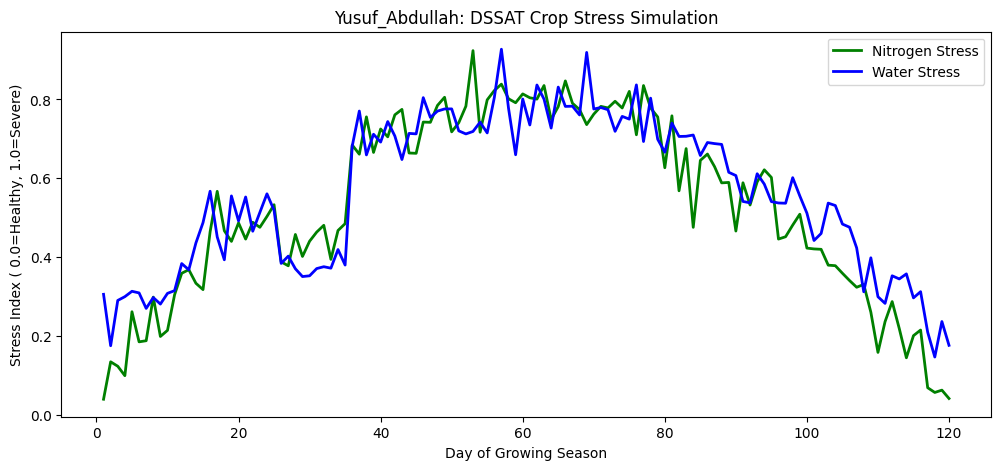

Plot saved as 'stress_timeseries.png'


In [101]:
#### DATA VISUALIZATION
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['day'], df['n_stress'], 'g-', linewidth=2, label='Nitrogen Stress')
ax.plot(df['day'], df['water_stress'], 'b-', linewidth=2, label='Water Stress')
ax.set_xlabel('Day of Growing Season')
ax.set_ylabel('Stress Index ( 0.0=Healthy, 1.0=Severe)')
ax.set_title('Yusuf_Abdullah: DSSAT Crop Stress Simulation')
ax.legend()
plt.savefig('stress_timeseries.png', dpi=150)
plt.show()
print("Plot saved as 'stress_timeseries.png'")

In [102]:
#### MODEL CREATION 
class SimpleLSTM(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size=2, hidden_size=32, num_layers=2, batch_first=True)
            #Output size of 2 stress(water and nitrogen) per day each week = 7 days * 2
            self.fc = nn.Linear(32, 14)

        def forward(self, x):
            out, _ =self.lstm(x)
            return self.fc(out[:, -1, :])


In [103]:
#### TRAINING DATA PREPARATION
SEQUENCE_LENGTH = 30
FORECAST_DAYS = 7

x, y = [], []
for i in range(len(df) - SEQUENCE_LENGTH - FORECAST_DAYS):
    x.append(df[['n_stress', 'water_stress']].iloc[i:i+SEQUENCE_LENGTH].values)
    y.append(df[['n_stress', 'water_stress']].iloc[i+SEQUENCE_LENGTH:i+SEQUENCE_LENGTH+FORECAST_DAYS].values.flatten())

x = torch.FloatTensor(np.array(x))
y = torch.FloatTensor(np.array(y))


Epoch 10/50, Loss: 0.3171
Epoch 20/50, Loss: 0.1990
Epoch 30/50, Loss: 0.0581
Epoch 40/50, Loss: 0.0344
Epoch 50/50, Loss: 0.0328


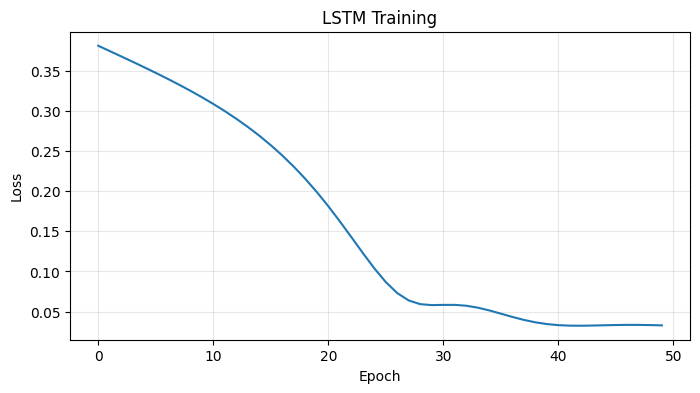

 LSTM training complete. Final loss: 0.0328


In [104]:
#### TRAINING LSTM
lstm = SimpleLSTM()
optimizer = torch.optim.Adam(lstm.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

losses = []
for epoch in range(50):
    predictions = lstm(x)
    loss = loss_fn(predictions, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50, Loss: {loss.item():.4f}")

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training')
plt.grid(alpha=0.3)
plt.show()

print(f" LSTM training complete. Final loss: {losses[-1]:.4f}")

In [105]:
#### SIMULATING REFLECTANCE
def generate_spectra(chlorophy, leaf_area_index, n_bands=100):
    """Simulate reflectance spectra from chlorophyII content in the leaves and leaf area index"""
    wavelengths = np.linspace(400, 2500, n_bands)
    
    # Green peak at 550nm
    green_peak= np.exp(-((wavelengths - 550) / 50)**2)
    
    # Red edge shifts with chlorophyII
    red_edge_position = 680 + chlorophy / 5
    red_edge = 1 / (1 + np.exp(-(wavelengths - red_edge_position) / 20))
    
    # Changed from Leaf area index
    leaf_effect = 1 - np.exp(-leaf_area_index / 2)
    
    reflectance = 0.05 + 0.3 * green_peak * red_edge * leaf_effect
    return np.clip(reflectance, 0.01, 0.6)



In [106]:
#### SPECTRA SIMULATION (FORWARD MODEL)
def generate_spectra(chlorophy, leaf_area_index, n_bands=100):
    wavelengths = np.linspace(400, 2500, n_bands)
    green_peak = np.exp(-((wavelengths - 550) / 50)**2)
    red_edge_position = 680 + chlorophy / 5
    red_edge = 1 / (1 + np.exp(-(wavelengths - red_edge_position) / 20))
    leaf_area_index_effect = 1 - np.exp(-leaf_area_index / 2)
    reflectance = 0.05 + 0.3 * green_peak * red_edge * leaf_area_index_effect
    reflectance += np.random.normal(0, 0.0, n_bands)
    return np.clip(reflectance, 0.01, 0.6)

In [107]:
#### INVERSION NETWORK CREATION
class InversionNN(nn.Module):
    def __init__(self, input_size=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            # chlorophy, leaf_area_index
            nn.Linear(64, 2) 
        )
    
    def forward(self, x):
        return self.net(x)

In [108]:
#### GENERATING DATA FOR INVERSION
N_SAMPLES = 5000
chlorophy_values = np.random.uniform(10, 80, N_SAMPLES)
leaf_area_index_values = np.random.uniform(0.5, 6, N_SAMPLES)

spectra = []
for chlorophy, leaf_area_index in zip(chlorophy_values, leaf_area_index_values):
    spectra.append(generate_spectra(chlorophy, leaf_area_index))
spectra = np.array(spectra)

print(f"Chlorophy range: {chlorophy_values.min():.1f} - {chlorophy_values.max():.1f}")
print(f"Leaf_area_index range: {leaf_area_index_values.min():.1f} - {leaf_area_index_values.max():.1f}")

Chlorophy range: 10.0 - 80.0
Leaf_area_index range: 0.5 - 6.0


Epoch 20/100, Loss: 0.4284
Epoch 40/100, Loss: 0.1604
Epoch 60/100, Loss: 0.0508
Epoch 80/100, Loss: 0.0275
Epoch 100/100, Loss: 0.0194
Epoch 120/100, Loss: 0.0150
Epoch 140/100, Loss: 0.0121
Epoch 160/100, Loss: 0.0101
Epoch 180/100, Loss: 0.0087
Epoch 200/100, Loss: 0.0075


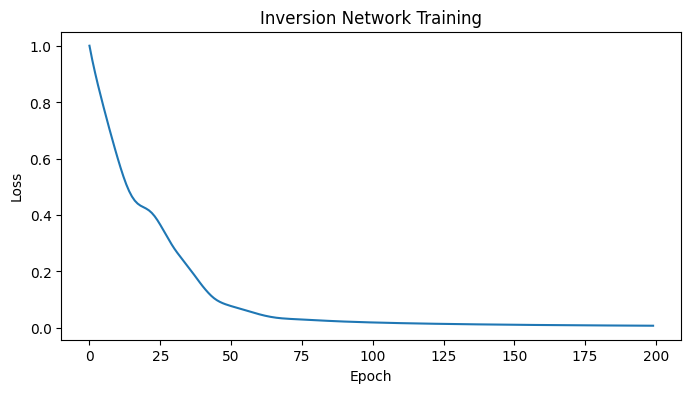

Final loss: 0.0075


In [109]:
#### TRAINING INVERSION NETWORK
#First, I normalize the data
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_spec = scaler_x.fit_transform(spectra)
y_params = scaler_y.fit_transform(np.column_stack([chlorophy_values, leaf_area_index_values]))

# Training
inversion_network = InversionNN()
optimizer = torch.optim.Adam(inversion_network.parameters(), lr=0.001)

inversion_losses = []
for epoch in range(200):
    pred = inversion_network(torch.FloatTensor(x_spec))
    loss = nn.MSELoss()(pred, torch.FloatTensor(y_params))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    inversion_losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {loss.item():.4f}")

# Ploting training curve
plt.figure(figsize=(8, 4))
plt.plot(inversion_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Inversion Network Training')
plt.show()
print(f"Final loss: {inversion_losses[-1]:.4f}")

In [110]:
#### TESTING THE INVERSION NETWORK
# Generating the test data
N_TEST = 2000
test_chlorophy = np.random.uniform(10, 80, N_TEST)
test_leaf_area_index = np.random.uniform(0.5, 6, N_TEST)

test_spectra = []
for chlorophy, leaf_area_index in zip(test_chlorophy, test_leaf_area_index):
    test_spectra.append(generate_spectra(chlorophy, leaf_area_index))
test_spectra = np.array(test_spectra)

# Normalizing and then predicting
test_scaled = scaler_x.transform(test_spectra)
with torch.no_grad():
    pred_scaled = inversion_network(torch.FloatTensor(test_scaled)).numpy()
    predictions = scaler_y.inverse_transform(pred_scaled)

# Calculating R² scores
r2_chlorophy = r2_score(test_chlorophy, predictions[:, 0])
r2_leaf_area_index = r2_score(test_leaf_area_index, predictions[:, 1])

print(f"Chlorophy retrieval:  R² = {r2_chlorophy:.4f}")
print(f"Leaf Area Index retrieval:  R² = {r2_leaf_area_index:.4f}")

Chlorophy retrieval:  R² = 0.9922
Leaf Area Index retrieval:  R² = 0.9928


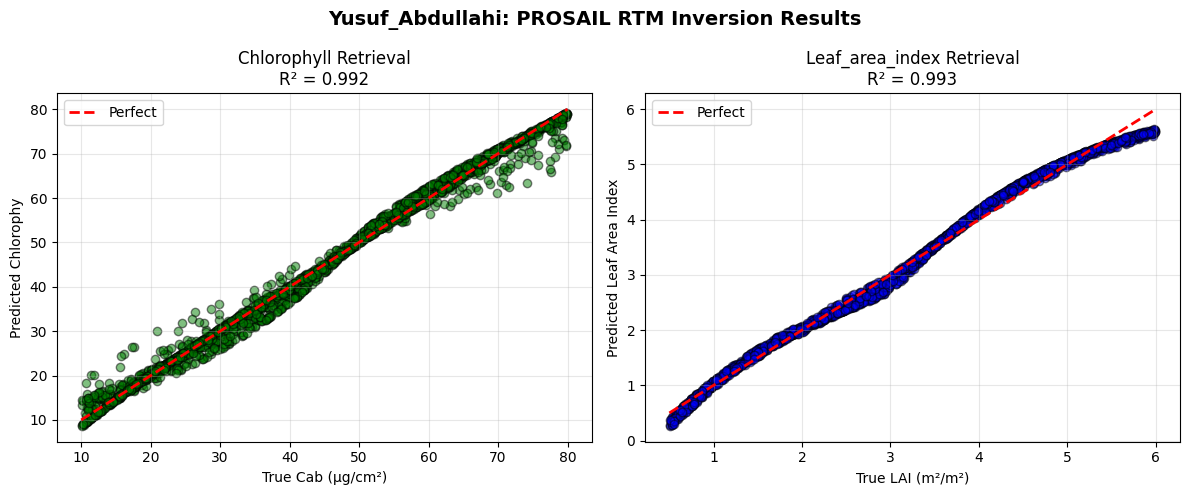

 Plot saved as 'inversion_results.png'


In [111]:
#### VISUALIZING THE TRAINED RESULTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chlorophy plot
ax1.scatter(test_chlorophy, predictions[:, 0], alpha=0.5, c='green', edgecolors='black')
ax1.plot([10, 80], [10, 80], 'r--', linewidth=2, label='Perfect')
ax1.set_xlabel('True Cab (μg/cm²)')
ax1.set_ylabel('Predicted Chlorophy')
ax1.set_title(f'Chlorophyll Retrieval\nR² = {r2_chlorophy:.3f}')
ax1.legend()
ax1.grid(alpha=0.3)

# Leaf Area Index plot
ax2.scatter(test_leaf_area_index, predictions[:, 1], alpha=0.5, c='blue', edgecolors='black')
ax2.plot([0.5, 6], [0.5, 6], 'r--', linewidth=2, label='Perfect')
ax2.set_xlabel('True LAI (m²/m²)')
ax2.set_ylabel('Predicted Leaf Area Index')
ax2.set_title(f'Leaf_area_index Retrieval\nR² = {r2_leaf_area_index:.3f}')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Yusuf_Abdullahi: PROSAIL RTM Inversion Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inversion_results.png', dpi=150)
plt.show()
print(" Plot saved as 'inversion_results.png'")